<a href="https://colab.research.google.com/github/24cseaiml040nilamanikundu/DMPM_LAB/blob/main/ASSiGNMENT-7/DMPM_LAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [2]:
x=np.array([[2,3],[3,4],[4,3],[10,11],[11,12],[12,11]])
print(x)

[[ 2  3]
 [ 3  4]
 [ 4  3]
 [10 11]
 [11 12]
 [12 11]]


In [4]:
#Apply K-Means
kmeans=KMeans(n_clusters=2,random_state=42, n_init=10)
labels=kmeans.fit_predict(x)
print("Cluster Labels:")
print(labels)

Cluster Labels:
[0 0 0 1 1 1]


In [6]:
print("\nCluster centers")
print(kmeans.cluster_centers_)


Cluster centers
[[ 3.          3.33333333]
 [11.         11.33333333]]


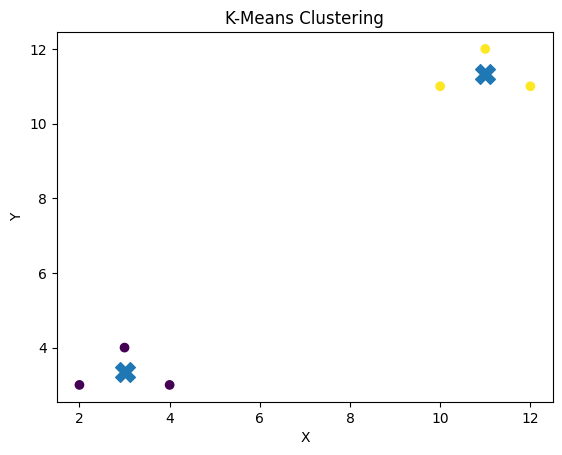

In [13]:
#plot cluster
plt.scatter(x[:,0],x[:,1],c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=200,marker='X')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Means Clustering")
plt.show()

In [14]:
k=2
medoid_indices=[0,3]

Cluster labels:
[0 0 0 1 1 1]

Medoid Points:
[3 4]
[11 12]


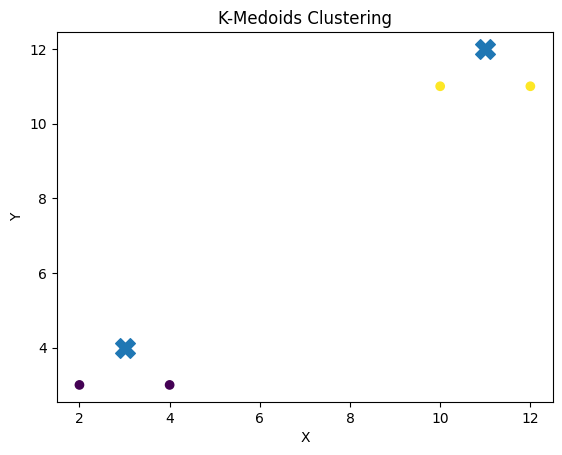

In [22]:
while True:
    distances = np.zeros((len(x), k))

    for i in range(len(x)):
        for j in range(k):
            distances[i, j] = np.linalg.norm(
                x[i] - x[medoid_indices[j]]
            )

    labels = np.argmin(distances, axis=1)
    new_medoid_indices = []
    for cluster in range(k):
        cluster_indices = np.where(labels == cluster)[0]
        if len(cluster_indices) == 0:
            new_medoid_indices.append(medoid_indices[cluster])
            continue
        total_distance=[]
        for i in cluster_indices:
          total=0
          for j in cluster_indices:
            total+=np.linalg.norm(x[i]-x[j])
          total_distance.append(total)
        new_medoid_indices.append(cluster_indices[np.argmin(total_distance)])
    if new_medoid_indices == medoid_indices:
        break
    medoid_indices = new_medoid_indices
print("Cluster labels:")
print(labels)

print("\nMedoid Points:")
for index in medoid_indices:
    print(x[index])

plt.scatter(x[:,0],x[:,1],c=labels)
plt.scatter(x[medoid_indices,0],x[medoid_indices,1],s=200,marker='X')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("K-Medoids Clustering")
plt.show()